## Training Curve: Does the Hard-Pool Gap Close with More Training?

Vanilla InfoNCE at 2K steps gives P@1-target = 0.382 on the 5-language hard pool while P@1-any stays at 1.000 — the model always finds the right meaning but often in the wrong language. One explanation is undertraining: maybe more steps would teach it to prefer the target language.

The curve rules that out. P@1-any = 1.000 at every checkpoint. P@1-target drops from 0.382 at 2K to 0.259 at 10K before partially recovering to 0.297 at 20K — the gap grows from 0.61 to 0.74 and never closes. More InfoNCE training actively makes language discrimination worse. The objective pushes all translations toward the same point regardless of language, so additional steps collapse cross-lingual representations further and erode whatever language specificity the pretrained model had.

In [2]:
!pip install -q transformers datasets torch

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MAX_STEPS        = 20000
BATCH_SIZE       = 32
LR               = 2e-5
TEMPERATURE      = 0.07
WARMUP_STEPS     = 200
LOG_EVERY        = 500
CHECKPOINT_STEPS = [2000, 5000, 10000, 20000]

Device: cuda


In [3]:
from huggingface_hub import notebook_login
notebook_login()

In [4]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=2048, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, output_dim))
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class XLMRWrapper(nn.Module):
    def __init__(self, model_name='xlm-roberta-base'):
        super().__init__()
        self.model = XLMRobertaModel.from_pretrained(model_name)
        self.projection = ProjectionHead(768, 2048, 256)

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return self.projection(self._mean_pool(out.last_hidden_state, attention_mask))

    def encode(self, input_ids, attention_mask):
        # raw encoder output, no projection head
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return self._mean_pool(out.last_hidden_state, attention_mask)

    @staticmethod
    def _mean_pool(hidden, mask):
        m = mask.unsqueeze(-1).float()
        return F.normalize((hidden * m).sum(1) / m.sum(1).clamp(min=1e-9), dim=-1)

tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')

def collate(pairs, max_length=128):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc

def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        yield ex['translation'][src_lang], ex['translation'][tgt_lang]

def infonce_loss(z_src, z_tgt, tau=TEMPERATURE):
    sim = z_src @ z_tgt.T / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2.0

print('Model and utilities loaded.')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model and utilities loaded.


## Load FLORES-200 and Define Evaluation

In [ ]:
LANG_CODES = {
    'es': 'spa_Latn',
    'fr': 'fra_Latn',
    'de': 'deu_Latn',
    'sw': 'swh_Latn',
    'ar': 'arb_Arab',
}

def load_flores(lang_code, split='devtest'):
    ds = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [ex['text'] for ex in ds]

print('Loading FLORES-200 devtest...')
en_sents   = load_flores('eng_Latn')
lang_sents = {lang: load_flores(code) for lang, code in LANG_CODES.items()}
N = len(en_sents)
print(f'{N} sentences per language, hard pool = {N * len(LANG_CODES)}')

@torch.no_grad()
def encode_all(mdl):
    # 768-dim encoder output, no projection head
    def enc(sents):
        out = []
        for i in range(0, len(sents), 256):
            batch = sents[i:i+256]
            tok = tokenizer(batch, padding=True, truncation=True,
                            max_length=128, return_tensors='pt')
            tok = {k: v.to(DEVICE) for k, v in tok.items()}
            out.append(mdl.encode(tok['input_ids'], tok['attention_mask']).cpu())
        return torch.cat(out, 0)
    en = enc(en_sents)
    langs = {lang: enc(lang_sents[lang]) for lang in LANG_CODES}
    return en, langs

def evaluate(mdl):
    mdl.eval()
    en_embs, lang_embs = encode_all(mdl)

    # P@1-easy: EN vs ES only
    sim_easy = en_embs @ lang_embs['es'].T
    p1_easy  = float((sim_easy.argmax(1) == torch.arange(N)).float().mean())

    # hard pool layout: ES (0..N) | FR (N..2N) | DE (2N..3N) | SW (3N..4N) | AR (4N..5N)
    hard_pool = torch.cat([lang_embs[l] for l in LANG_CODES], dim=0)
    top1      = (en_embs @ hard_pool.T).argmax(dim=1)

    p1_target = float((top1 == torch.arange(N)).float().mean())

    # multiway parallel: any k*N+i where i matches is also semantically correct
    p1_any = float((top1 % N == torch.arange(N)).float().mean())

    return p1_easy, p1_target, p1_any

print('Eval ready.')

## Training Loop

Trains to 20K steps with eval checkpoints at 2K, 5K, 10K, and 20K. If all four `.pt` files are already present (e.g. uploaded from a prior run), training is skipped and the checkpoints are evaluated directly.

In [ ]:
all_ckpts_exist = all(
    os.path.exists(f'vanilla_infonce_{s}steps_enes.pt') for s in CHECKPOINT_STEPS
)

if all_ckpts_exist:
    print('All checkpoints found — skipping training, evaluating loaded checkpoints...\n')
    curve = []
    for s in CHECKPOINT_STEPS:
        ckpt  = torch.load(f'vanilla_infonce_{s}steps_enes.pt', map_location=DEVICE)
        model = XLMRWrapper('xlm-roberta-base').to(DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        p1_easy, p1_target, p1_any = evaluate(model)
        curve.append((s, p1_easy, p1_target, p1_any))
        print(f'  step {s:>5}: P@1-easy={p1_easy:.4f}  P@1-target={p1_target:.4f}  P@1-any={p1_any:.4f}')
    del model
    print('\nDone.')

else:
    model     = XLMRWrapper('xlm-roberta-base').to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(optimizer, WARMUP_STEPS, MAX_STEPS)

    model.train()
    train_iter = opus_stream('en-es', seed=42)
    buf, step  = [], 0
    losses     = []
    curve      = []   # (step, p1_easy, p1_target, p1_any)

    print(f'Training to {MAX_STEPS} steps, evaluating at {CHECKPOINT_STEPS}...\n')

    for src_text, tgt_text in train_iter:
        buf.append((src_text, tgt_text))
        if len(buf) < BATCH_SIZE:
            continue

        src_enc, tgt_enc = collate(buf); buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}
        z_src = model(src_enc['input_ids'], src_enc['attention_mask'])
        z_tgt = model(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        loss  = infonce_loss(z_src, z_tgt)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        step += 1
        losses.append(loss.item())

        if step % LOG_EVERY == 0:
            avg = sum(losses[-LOG_EVERY:]) / LOG_EVERY
            print(f'  step {step:>5}/{MAX_STEPS}  loss={avg:.4f}')

        if step in CHECKPOINT_STEPS:
            print(f'\ncheckpoint at step {step}')
            p1_easy, p1_target, p1_any = evaluate(model)
            curve.append((step, p1_easy, p1_target, p1_any))
            print(f'  P@1-easy={p1_easy:.4f}  P@1-target={p1_target:.4f}  P@1-any={p1_any:.4f}')

            ckpt_path = f'vanilla_infonce_{step}steps_enes.pt'
            torch.save({'model_state_dict': model.state_dict(), 'step': step}, ckpt_path)
            print(f'  saved {ckpt_path}  ({os.path.getsize(ckpt_path)/1e6:.0f} MB)\n')
            model.train()

        if step >= MAX_STEPS:
            break

    del optimizer, scheduler
    print('Training complete.')

## Results

P@1-easy sits at ceiling (~0.99–1.00) the whole time and P@1-any = 1.000 at every checkpoint — the model consistently finds the right sentence, just not always in Spanish. The failure is entirely in language selection: P@1-target drops from 0.382 at 2K to 0.259 at 10K before partially recovering to 0.297 at 20K. The gap grows from 0.61 to 0.74 before settling at 0.70.

More training makes things worse through at least 10K steps. InfoNCE has no loss term for language identity — its only signal is semantic match — so as the model gets better at collapsing same-meaning sentences together across languages, it gets worse at keeping them apart by language. This rules out undertraining as an explanation and makes a training-time fix that explicitly conditions on target language clearly necessary.

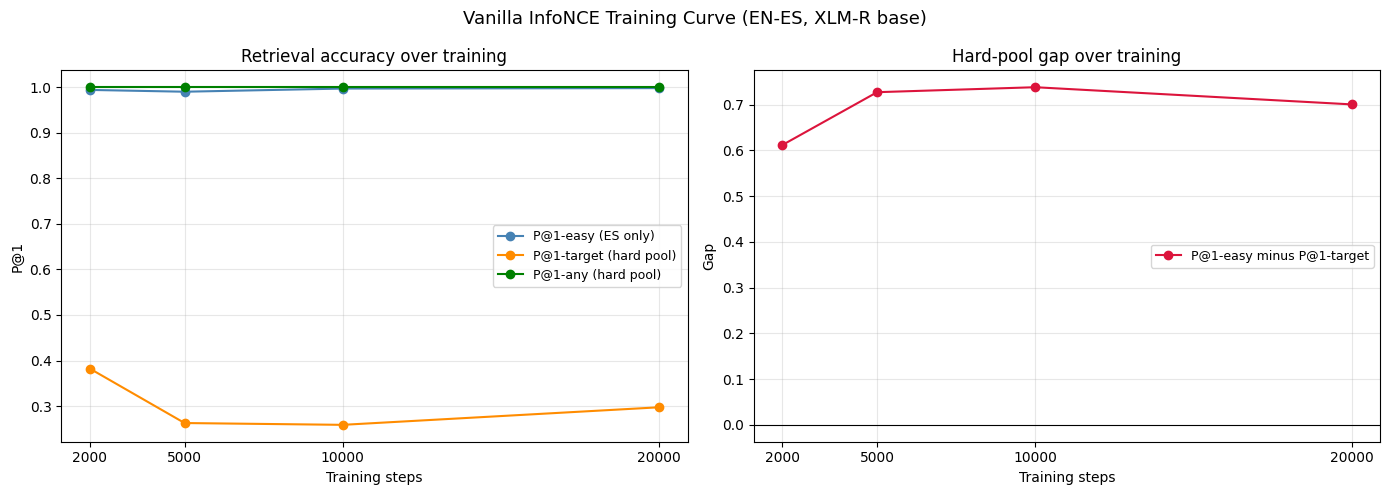


=== Training Curve Summary ===
   Steps    P@1-easy   P@1-target    P@1-any       Gap
------------------------------------------------------
    2000      0.9941       0.3824     1.0000    0.6117
    5000      0.9901       0.2628     1.0000    0.7273
   10000      0.9970       0.2589     1.0000    0.7381
   20000      0.9980       0.2974     1.0000    0.7006

Gap at 2000  steps: 0.6117
Gap at 20000 steps: 0.7006
Gap persists at 20K steps -- failure is structural, not undertraining.


In [7]:
steps_  = [r[0] for r in curve]
easy_   = [r[1] for r in curve]
target_ = [r[2] for r in curve]
any_    = [r[3] for r in curve]
gap_    = [e - t for e, t in zip(easy_, target_)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vanilla InfoNCE Training Curve (EN-ES, XLM-R base)', fontsize=13)

ax = axes[0]
ax.plot(steps_, easy_,   'o-', color='steelblue',  label='P@1-easy (ES only)')
ax.plot(steps_, target_, 'o-', color='darkorange', label='P@1-target (hard pool)')
ax.plot(steps_, any_,    'o-', color='green',      label='P@1-any (hard pool)')
ax.set_xlabel('Training steps')
ax.set_ylabel('P@1')
ax.set_title('Retrieval accuracy over training')
ax.set_xticks(steps_)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(steps_, gap_, 'o-', color='crimson', label='P@1-easy minus P@1-target')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Training steps')
ax.set_ylabel('Gap')
ax.set_title('Hard-pool gap over training')
ax.set_xticks(steps_)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

print('\n=== Training Curve Summary ===')
print(f'{"Steps":>8}  {"P@1-easy":>10}  {"P@1-target":>11}  {"P@1-any":>9}  {"Gap":>8}')
print('-' * 54)
for s, e, t, a in curve:
    print(f'{s:>8}  {e:>10.4f}  {t:>11.4f}  {a:>9.4f}  {e-t:>8.4f}')

final_gap   = easy_[-1]  - target_[-1]
initial_gap = easy_[0]   - target_[0]
print(f'\nGap at {steps_[0]}  steps: {initial_gap:.4f}')
print(f'Gap at {steps_[-1]} steps: {final_gap:.4f}')
if final_gap < 0.2:
    print('Gap closed substantially -- undertraining was a significant factor.')
elif final_gap > 0.5:
    print('Gap persists at 20K steps -- failure is structural, not undertraining.')
else:
    print('Gap narrowed but not closed -- partial undertraining effect.')

In [8]:
# download all saved checkpoints
from google.colab import files
for step in CHECKPOINT_STEPS:
    path = f'vanilla_infonce_{step}steps_enes.pt'
    if os.path.exists(path):
        files.download(path)
        print(f'Downloading {path}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>